In [1]:
# TODO: add comments below Hierarchical Triangle Mesh section

# Global Ocean Mesh comparison

In this notebook different meshes for the data-driven model under development are explored. The first is the icosahedral multi-mesh used by GraphCast as is, the second is a masked version of the previous, finally, a hierarchical triangle mesh obtained with `seamsh` has been considered.

In [2]:
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import xarray as xr
from geopy.geocoders import Nominatim

from graphcast import dataset_utils
from graphcast import icosahedral_mesh
from graphcast import mesh_connectivity
from graphcast import mesh_graph
from graphcast import model
from graphcast import ocean_mesh_utils
from graphcast import plot_utils

In [3]:
save_figures = True

output_dir = Path('outputs/mesh_comparison')
if not output_dir.exists():
  output_dir.mkdir(parents=True)

In [4]:
# The zoom-ins will be around the following area.
geolocator = Nominatim(user_agent="mesh_comparison")
location = geolocator.geocode("Rome")
width, height = 10.0, 10.0
bounds = [location.longitude - width / 2, location.longitude + width / 2,
          location.latitude - height / 2, location.latitude + height / 2]

In [5]:
dataset = xr.open_dataset('../data/dataset/dataset_tres-1d_res-0p25_levels-10/', engine='zarr')
dataset

<xarray.Dataset> Size: 2GB
Dimensions:                              (time: 7, lat: 721, lon: 1440,
                                          level: 10)
Coordinates:
    depth                                (level) float32 40B ...
  * lat                                  (lat) float32 3kB -90.0 -89.75 ... 90.0
  * level                                (level) int64 80B 0 4 8 12 ... 28 32 34
  * lon                                  (lon) float32 6kB 0.0 0.25 ... 359.8
  * time                                 (time) datetime64[ns] 56B 2000-01-01...
Data variables: (12/33)
    10m_u_component_of_wind              (time, lat, lon) float32 29MB ...
    10m_v_component_of_wind              (time, lat, lon) float32 29MB ...
    2m_dewpoint_temperature              (time, lat, lon) float32 29MB ...
    2m_temperature                       (time, lat, lon) float32 29MB ...
    deptho                               (lat, lon) float32 4MB ...
    dis24                                (time, lat, lon) float32 29MB ...
    ...                                   ...
    vsdy                                 (time, lat, lon) float32 29MB ...
    vsi                                  (time, lat, lon) float32 29MB ...
    vtm02                                (time, lat, lon) float32 29MB ...
    waverys_deptho                       (lat, lon) float32 4MB ...
    waverys_mask                         (lat, lon) bool 1MB ...
    zos                                  (time, lat, lon) float32 29MB ...
Attributes:
    last_updated:           2025-07-17 01:52:23.900829+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-04-30
    valid_time_stop_era5t:  2025-07-11

## Icosahedral Multi-Mesh

In [6]:
# Icosahedral hierarchical meshes are 3-dimensional and defined on a unit sphere.
# They will be projected on the reference geoid via PROJ, using `mesh_to_wgs`
SPLITS = 6

mesh_hierarchy = icosahedral_mesh.get_hierarchy_of_triangular_meshes_for_sphere(splits=SPLITS)

In [7]:
def hierarchy_to_nx(meshes):
    multimesh = mesh_graph.merge_meshes(meshes)
    wgs_graph = mesh_graph.mesh_to_wgs(multimesh)
    nx_graph = mesh_graph.wgs_to_nx(wgs_graph)
    nx_graph.add_edges_from(zip(*multimesh.edges))
    return nx_graph

In [8]:
mesh_graph.graph_summary(hierarchy_to_nx(mesh_hierarchy))

'Nodes: 40962, Edges: 327660, Average degree: 15.998242273326497'

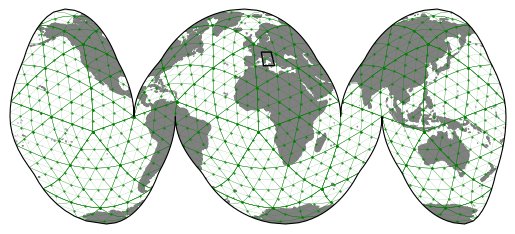

In [9]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.InterruptedGoodeHomolosine(emphasis='ocean'))
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='grey'))

# Plot refinement levels separately, with thinner edges for finer meshes
for (split, mesh) in enumerate(mesh_hierarchy[:4]):

  wgs_graph = mesh_graph.mesh_to_wgs(mesh, unit_sphere=True)
  lc = plot_utils.get_line_collection(wgs_graph, linewidths=0.08 * (4 - split), colors="green", transform=ccrs.Geodetic())
  ax.add_collection(lc)
  latitudes, longitudes = wgs_graph.vertices
  ax.scatter(longitudes, latitudes, marker='.', color="green", s=(4 - split), zorder=2, transform=ccrs.PlateCarree())

# Add a rectangle patch around zoom-in
ax.add_patch(mpatches.Rectangle(xy=(location.longitude - width / 2, location.latitude - height / 2), width=width, height=height,
                                facecolor='none', edgecolor='k', zorder=3, transform=ccrs.PlateCarree()))
if save_figures:
    plt.savefig(output_dir / 'icosahedral_multimesh.png', bbox_inches='tight')

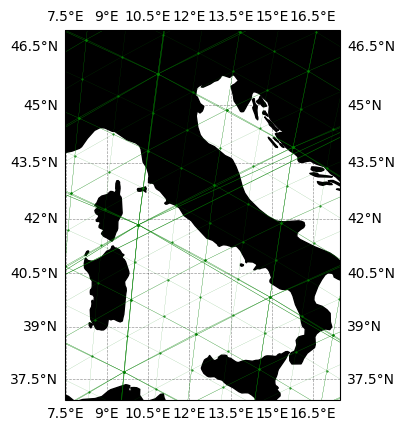

In [10]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.set_extent(bounds)
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='black'))
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.4, color='k', linestyle='--')

# Plot refinement levels separately, with thinner edges for finer meshes
for (split, mesh) in enumerate(mesh_hierarchy):

  wgs_graph = mesh_graph.mesh_to_wgs(mesh, unit_sphere=True)
  lc = plot_utils.get_line_collection(wgs_graph, linewidths=0.08 * (7 - split), colors="green", transform=ccrs.Geodetic())
  ax.add_collection(lc)
  latitudes, longitudes = wgs_graph.vertices
  ax.scatter(longitudes, latitudes, marker='.', color="green", s=(7 - split), zorder=2, transform=ccrs.PlateCarree())

if save_figures:
    plt.savefig(output_dir / 'icosahedral_multimesh_zoomin.png', bbox_inches='tight')

In [11]:
mask = dataset[['glorys_mask']].isel(level=0, drop=True)
mask = dataset_utils.Process().regrid(mask, method='conservative', latitude_dim='lat', longitude_dim='lon', 
                kwargs={'skipna': True},
                grid={'south': -90.0, 'north': 90.0, 'west': 0.0, 'east': 359.5, 'resolution_lat': 0.5, 'resolution_lon': 0.5})
mask = mask['glorys_mask']
mask = mask.astype(bool)
mask

<xarray.DataArray 'glorys_mask' (lat: 361, lon: 720)> Size: 260kB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(361, 720))
Coordinates:
  * lat      (lat) float32 1kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * lon      (lon) float32 3kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5

In [12]:
# Multi-mesh masking is per refinement level, as it depends on `_get_max_edge_distance(mesh)`,
# here we select only the first 4 levels and se `RADIUS_QUERY_FRACTION_EDGE_LENGTH` accordingly.
RADIUS_QUERY_FRACTION_EDGE_LENGTH = 0.2

coarse_multimesh = mesh_graph.merge_meshes(mesh_hierarchy[:4])
connected_mesh_nodes = mesh_connectivity.get_connected_mesh_nodes(grid_lat=mask.lat,
                                                                  grid_lon=mask.lon,
                                                                  mesh_graph=coarse_multimesh,
                                                                  grid_mask=mask,
                                                                  query_radius=model._get_max_edge_distance(coarse_multimesh) * RADIUS_QUERY_FRACTION_EDGE_LENGTH)
masked_coarse_multimesh = mesh_connectivity.mask_mesh(marked_vertices=connected_mesh_nodes, mesh=coarse_multimesh)

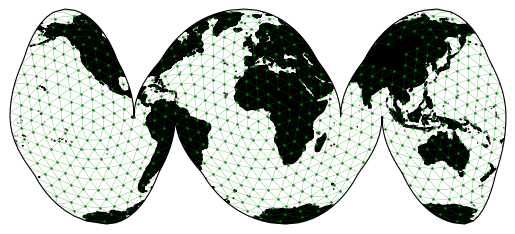

In [13]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.InterruptedGoodeHomolosine(emphasis='ocean'))
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='black'))

# Masking operates on `MultiMeshGraph`, which is *not* a hierarchical mesh, as it stores faces only for the finest mesh.
# As for GraphCast, this piece of information is enough, because faces are used only in the decoder, which requires only the latter.
masked_coarse_wgs_graph = mesh_graph.mesh_to_wgs(masked_coarse_multimesh, unit_sphere=True)
lc = plot_utils.get_line_collection(masked_coarse_wgs_graph, linewidths=0.16, colors="green", transform=ccrs.Geodetic())
ax.add_collection(lc)
latitudes, longitudes = masked_coarse_wgs_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="green", s=2.0, zorder=2, transform=ccrs.PlateCarree())

if save_figures:
    plt.savefig(output_dir / 'masked_icosahedral_multimesh.png', bbox_inches='tight')

In [14]:
# Adjust `RADIUS_QUERY_FRACTION_EDGE_LENGTH` to work with 6 levels of refinement,
# i.e. the multi-mesh used in GraphCast paper.
RADIUS_QUERY_FRACTION_EDGE_LENGTH = 0.6

fine_multimesh = mesh_graph.merge_meshes(mesh_hierarchy)
connected_mesh_nodes = mesh_connectivity.get_connected_mesh_nodes(grid_lat=mask.lat,
                                                                  grid_lon=mask.lon,
                                                                  mesh_graph=fine_multimesh,
                                                                  grid_mask=mask,
                                                                  query_radius=model._get_max_edge_distance(fine_multimesh) * RADIUS_QUERY_FRACTION_EDGE_LENGTH)
masked_fine_multimesh = mesh_connectivity.mask_mesh(marked_vertices=connected_mesh_nodes, mesh=fine_multimesh)

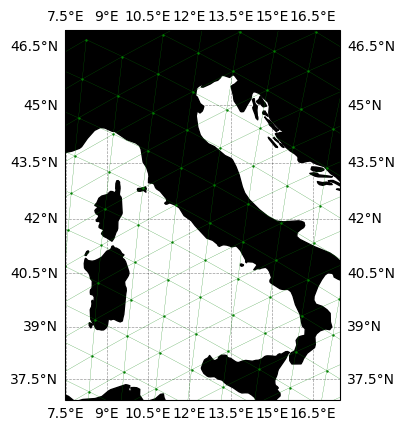

In [15]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.set_extent(bounds)
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='black'))
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.4, color='k', linestyle='--')

masked_fine_wgs_graph = mesh_graph.mesh_to_wgs(masked_fine_multimesh, unit_sphere=True)
lc = plot_utils.get_line_collection(masked_fine_wgs_graph, linewidths=0.16, colors="green", transform=ccrs.Geodetic())
ax.add_collection(lc)
latitudes, longitudes = masked_fine_wgs_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="green", s=2.0, zorder=2, transform=ccrs.PlateCarree())

if save_figures:
    plt.savefig(output_dir / 'masked_icosahedral_multimesh_zoomin.png', bbox_inches='tight')

## Hierarchical Triangle Mesh

In [16]:
coarse_ocean_mesh = ocean_mesh_utils.read_mesh('../data/geometry/constant_size_coarse.msh')
coarse_ocean_mesh_graph = mesh_graph.mesh_to_wgs(coarse_ocean_mesh)

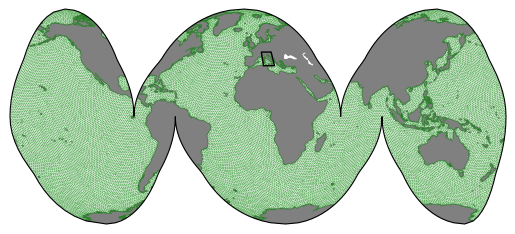

In [17]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.InterruptedGoodeHomolosine(emphasis='ocean'))
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='grey'))
latitudes, longitudes = coarse_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="green", s=2.0, zorder=2, alpha=0.0, transform=ccrs.PlateCarree())
lc = plot_utils.get_line_collection(coarse_ocean_mesh_graph, linewidths=0.16, colors="green", transform=ccrs.Geodetic())
ax.add_collection(lc)
ax.add_patch(mpatches.Rectangle(xy=(location.longitude - width / 2, location.latitude - height / 2), width=width, height=height,
                                facecolor='none', edgecolor='k', zorder=3, transform=ccrs.PlateCarree()))
if save_figures:
    plt.savefig(output_dir / 'coarse_ocean_mesh.png', bbox_inches='tight')

In [18]:
fine_ocean_mesh = ocean_mesh_utils.read_mesh('../data/geometry/constant_size_fine.msh')
fine_ocean_mesh_zoomin = mesh_connectivity.get_mesh_within_box(fine_ocean_mesh, bounds)
fine_ocean_mesh_graph_zoomin = mesh_graph.mesh_to_wgs(fine_ocean_mesh_zoomin)

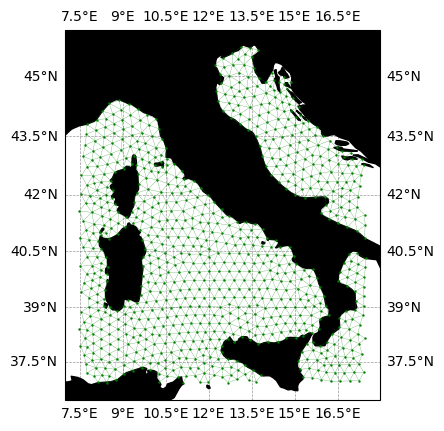

In [19]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='black'))
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.4, color='k', linestyle='--')
lc = plot_utils.get_line_collection(fine_ocean_mesh_graph_zoomin, linewidths=0.16, colors="green", transform=ccrs.Geodetic())
ax.add_collection(lc)
latitudes, longitudes = fine_ocean_mesh_graph_zoomin.vertices
ax.scatter(longitudes, latitudes, marker='.', color="green", s=2.0, zorder=2, transform=ccrs.PlateCarree())

if save_figures:
    plt.savefig(output_dir / 'fine_ocean_mesh_zoomin.png', bbox_inches='tight')